In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### **Exploring Data**

In [2]:
data = pd.read_csv('supply_chain_extended_data.csv')
data.sample(10)

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count
194,WH100,Los Angeles,1859,4489,5,4,23,34451,S211,Groceries,9634,0.505159,3.206536,1.102064,29322,18781,7428,269,47,59
316,WH277,Los Angeles,4884,3184,5,4,6,48757,S710,Furniture,1966,2.460037,0.664966,1.394510,28549,16441,14887,113,10,18
76,WH407,New York,2469,4680,2,4,10,69104,S878,Apparel,1013,1.087900,3.241581,4.480384,14179,4889,4214,4,29,6
498,WH204,Seattle,1821,536,9,6,23,78229,S966,Electronics,8828,1.298125,7.006858,1.150413,12831,7219,3575,204,24,48
25,WH376,San Francisco,3337,3349,5,5,10,88630,S566,Electronics,2070,0.800479,4.480423,3.587775,28749,10282,3061,207,38,61
335,WH294,Chicago,4251,650,10,3,23,57399,S607,Groceries,5765,3.608855,7.775085,1.183493,30399,7522,8792,215,12,61
43,WH459,New York,1295,2782,2,1,23,60363,S286,Electronics,2694,3.265891,2.930827,1.800825,24041,5744,2583,8,19,55
230,WH239,Miami,2435,3823,10,1,15,55720,S284,Groceries,3797,3.469365,3.163698,3.789322,46320,6255,7436,25,24,29
205,WH037,Houston,1389,1881,3,2,17,48242,S860,Apparel,2669,2.738094,1.126094,4.512628,16071,5523,4816,2,45,18
379,WH488,Denver,1769,2744,7,6,18,63690,S782,Apparel,6256,2.828760,3.182157,3.228623,18687,7616,14003,237,28,67


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Warehouse_ID           500 non-null    str    
 1   Location               500 non-null    str    
 2   Current_Stock          500 non-null    int64  
 3   Demand_Forecast        500 non-null    int64  
 4   Lead_Time_Days         500 non-null    int64  
 5   Shipping_Time_Days     500 non-null    int64  
 6   Stockout_Risk          500 non-null    int64  
 7   Operational_Cost       500 non-null    int64  
 8   Supplier_ID            500 non-null    str    
 9   Product_Category       500 non-null    str    
 10  Monthly_Sales          500 non-null    int64  
 11  Order_Processing_Time  500 non-null    float64
 12  Return_Rate            500 non-null    float64
 13  Customer_Rating        500 non-null    float64
 14  Warehouse_Capacity     500 non-null    int64  
 15  Storage_Cost     

In [4]:
data.describe()

,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,2722.822000,2957.050000,5.958000,3.948000,14.944000,65886.354000,5335.572000,2.750462,5.229366,3.090865,30032.818000,10263.83400,8001.086000,147.380000,24.684000,52.810000
std,1314.878786,1398.763988,2.630223,1.921635,5.923431,20283.576821,2619.353688,1.262967,2.661448,1.156971,11921.277948,5584.14567,4269.354045,87.880656,14.868298,27.888087
min,519.000000,402.000000,2.000000,1.000000,5.000000,30165.000000,1004.000000,0.505159,0.506755,1.004825,10338.000000,1083.00000,515.000000,0.000000,0.000000,5.000000
25%,1565.250000,1745.750000,4.000000,2.000000,10.000000,48731.750000,2978.000000,1.644623,3.085484,2.073853,19486.750000,5335.75000,4294.500000,71.750000,11.000000,28.000000
50%,2670.000000,3094.000000,6.000000,4.000000,15.000000,65733.500000,5234.000000,2.817771,5.128133,3.148014,29862.500000,10023.00000,7973.000000,141.000000,25.000000,53.000000
75%,3842.750000,4152.500000,8.000000,6.000000,20.000000,82900.250000,7550.750000,3.782273,7.406404,4.137274,40692.250000,15162.00000,11857.000000,224.000000,37.000000,78.000000
max,4998.000000,5200.000000,10.000000,7.000000,25.000000,99965.000000,9931.000000,4.954139,9.992465,4.998258,49979.000000,19979.00000,14988.000000,300.000000,50.000000,100.000000


In [5]:
print(f'Total warehouses including all regions : {data['Warehouse_ID'].nunique()}')
print(f'Number of suppliers including all regions : {data['Supplier_ID'].nunique()}')


Total warehouses including all regions : 313
Number of suppliers including all regions : 375


In [6]:
data.columns

Index(['Warehouse_ID', 'Location', 'Current_Stock', 'Demand_Forecast',
       'Lead_Time_Days', 'Shipping_Time_Days', 'Stockout_Risk',
       'Operational_Cost', 'Supplier_ID', 'Product_Category', 'Monthly_Sales',
       'Order_Processing_Time', 'Return_Rate', 'Customer_Rating',
       'Warehouse_Capacity', 'Storage_Cost', 'Transportation_Cost',
       'Backorder_Quantity', 'Damaged_Goods', 'Employee_Count'],
      dtype='str')

In [7]:
data['Product_Category'].value_counts()

Product_Category
Apparel        113
Groceries      105
Electronics    100
Furniture       93
Automotive      89
Name: count, dtype: int64

In [8]:
data['Location'].unique()

<StringArray>
[       'Dallas',       'Houston',       'Chicago',       'Atlanta',
 'San Francisco',      'New York',   'Los Angeles',       'Seattle',
         'Miami',        'Denver']
Length: 10, dtype: str

### **Implementing logic for  determining Warehouse house  Size.**

#### ***<font color="yellow">There are  three Distinct Problems in our Data:</font>***

Case 1 — Same ID + Same Location + Same Category + Different Supplier
    6 warehouse IDs affected
    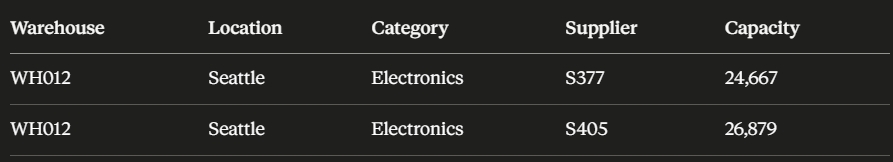

Case 2 — Same ID + Same Location + Different Category
    17 warehouse IDs affected
    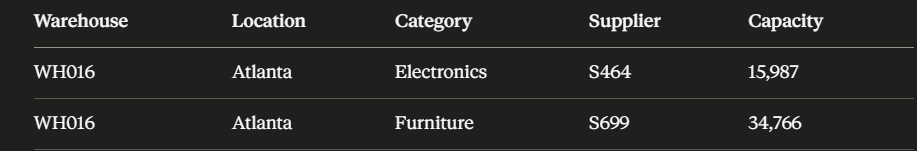

Case 3 — Same ID + Different Location
    125 warehouse IDs affected  
    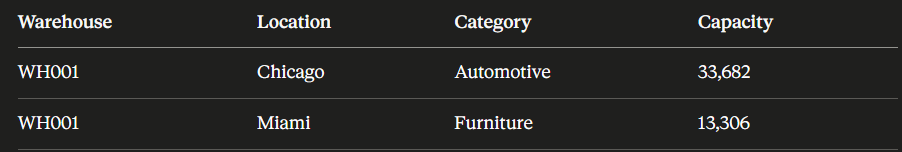

<Axes: ylabel='Density'>

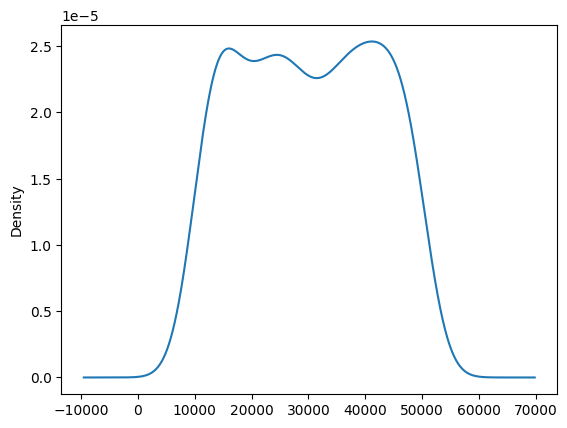

In [9]:
data['Warehouse_Capacity'].plot(kind='kde')

In [10]:
# So We can assume each row as different and apply pd.qcut 
# Categorizing the size of warehouse based on size 

warehouse_size_labels = ['small', 'medium', 'large']

data['Warehouse_Size'] = pd.qcut(data['Warehouse_Capacity'], q= 3 , labels= warehouse_size_labels , duplicates= 'raise')


###  **Implementing Logic for Montly Revenue , Salary and creating other features** 

In [11]:
# we have assumed the price in dollar
revenue_category_per_unit = {
    'Apparel' : 50,
    'Groceries' : 20,
    'Electronics' : 100,
    'Furniture'	: 200,
    'Automotive': 500
}

data['Revenue_Per_Unit'] = data['Product_Category'].map(revenue_category_per_unit)

# Calculated Monthly Revenue
data['Monthly_Revenue'] = data['Monthly_Sales'] * data['Revenue_Per_Unit']



In [12]:
'''# Calculated Employee Salary by assuming  average salary of employee in a month in  each city [  AVG(max(Salary) , min(Salary))  ]

# Google : {'New York': 7500, 'Chicago': 8000, 'Houston': 7000, 'Dallas' :7000,  'Atlanta':7500,'San Francisco' :9000, 'Los Angeles': 8000, 'Seattle':10000,'Miami':8000,'Denver':11000}
# chatgpt : {'New York': 6800, 'Chicago': 5200, 'Houston': 4600, 'Dallas' :4800,  'Atlanta':4700,'San Francisco' :7200, 'Los Angeles': 5900, 'Seattle':6300,'Miami': 4900,'Denver':5300}
# claude : {'New York': 7250, 'Chicago': 6000, 'Houston': 5750, 'Dallas' :5708,  'Atlanta':5583,'San Francisco' :7417, 'Los Angeles': 7000, 'Seattle':6833,'Miami': 5417,'Denver':5833}
salary_by_location = {
    'Dallas': 5708,
    'Houston': 5750,
    'Chicago': 6000,
    'Atlanta': 5583,
    'San Francisco': 7417,
    'New York': 7250,
    'Los Angeles': 7000,
    'Seattle': 6833,
    'Miami': 5417,
    'Denver': 5833,
}
data['Avg_Salary'] = data['Location'].map(salary_by_location)
data['Employee_Salary'] = data['Employee_Count'] * data['Avg_Salary']'''

"# Calculated Employee Salary by assuming  average salary of employee in a month in  each city [  AVG(max(Salary) , min(Salary))  ]\n\n# Google : {'New York': 7500, 'Chicago': 8000, 'Houston': 7000, 'Dallas' :7000,  'Atlanta':7500,'San Francisco' :9000, 'Los Angeles': 8000, 'Seattle':10000,'Miami':8000,'Denver':11000}\n# chatgpt : {'New York': 6800, 'Chicago': 5200, 'Houston': 4600, 'Dallas' :4800,  'Atlanta':4700,'San Francisco' :7200, 'Los Angeles': 5900, 'Seattle':6300,'Miami': 4900,'Denver':5300}\n# claude : {'New York': 7250, 'Chicago': 6000, 'Houston': 5750, 'Dallas' :5708,  'Atlanta':5583,'San Francisco' :7417, 'Los Angeles': 7000, 'Seattle':6833,'Miami': 5417,'Denver':5833}\nsalary_by_location = {\n    'Dallas': 5708,\n    'Houston': 5750,\n    'Chicago': 6000,\n    'Atlanta': 5583,\n    'San Francisco': 7417,\n    'New York': 7250,\n    'Los Angeles': 7000,\n    'Seattle': 6833,\n    'Miami': 5417,\n    'Denver': 5833,\n}\ndata['Avg_Salary'] = data['Location'].map(salary_by_lo

In [13]:
data['Employee_Salary'] =  data['Operational_Cost'] - (data['Storage_Cost'] + data['Transportation_Cost'])
data['Avg_Salary_Per_Employee'] = data['Employee_Salary'] / data['Employee_Count']

In [14]:
data['Total_Cost'] = data['Storage_Cost'] + data['Employee_Salary']+ data['Transportation_Cost']
data['Profit'] = data['Monthly_Revenue'] - data['Total_Cost']

In [15]:
data['Total_Delivery_Time'] = round(data['Order_Processing_Time'] + data['Shipping_Time_Days'])
data

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,...,Damaged_Goods,Employee_Count,Warehouse_Size,Revenue_Per_Unit,Monthly_Revenue,Employee_Salary,Avg_Salary_Per_Employee,Total_Cost,Profit,Total_Delivery_Time
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,...,26,83,medium,20,97860,74142,893.277108,93895,3965,8.0
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,...,16,39,medium,100,445300,31260,801.538462,46847,398453,10.0
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,...,3,49,small,200,1191200,40878,834.244898,64176,1127024,6.0
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,...,39,35,small,50,290700,8521,243.457143,38940,251760,9.0
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,...,30,67,large,100,227900,13018,194.298507,33933,193967,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,WH145,New York,4357,1521,10,5,20,65281,S830,Groceries,...,43,97,large,20,118180,57908,596.989691,65281,52899,9.0
496,WH181,Miami,3110,3322,4,7,8,88426,S663,Groceries,...,29,77,large,20,91680,74820,971.688312,88426,3254,11.0
497,WH068,Seattle,1636,4170,4,3,6,87751,S961,Apparel,...,38,61,small,50,84950,72331,1185.754098,87751,-2801,4.0
498,WH204,Seattle,1821,536,9,6,23,78229,S966,Electronics,...,24,48,small,100,882800,67435,1404.895833,78229,804571,7.0


In [16]:
data['Fulfillment_Rate']= data['Current_Stock'] / data['Demand_Forecast']


In [17]:
data['Warehouse_Utilization_Ratio']= data['Current_Stock'] / data['Warehouse_Capacity']
data

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,...,Warehouse_Size,Revenue_Per_Unit,Monthly_Revenue,Employee_Salary,Avg_Salary_Per_Employee,Total_Cost,Profit,Total_Delivery_Time,Fulfillment_Rate,Warehouse_Utilization_Ratio
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,...,medium,20,97860,74142,893.277108,93895,3965,8.0,8.111570,0.136790
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,...,medium,100,445300,31260,801.538462,46847,398453,10.0,0.591956,0.083762
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,...,small,200,1191200,40878,834.244898,64176,1127024,6.0,1.096707,0.209050
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,...,small,50,290700,8521,243.457143,38940,251760,9.0,2.855856,0.168463
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,...,large,100,227900,13018,194.298507,33933,193967,11.0,0.170101,0.020419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,WH145,New York,4357,1521,10,5,20,65281,S830,Groceries,...,large,20,118180,57908,596.989691,65281,52899,9.0,2.864563,0.091340
496,WH181,Miami,3110,3322,4,7,8,88426,S663,Groceries,...,large,20,91680,74820,971.688312,88426,3254,11.0,0.936183,0.063904
497,WH068,Seattle,1636,4170,4,3,6,87751,S961,Apparel,...,small,50,84950,72331,1185.754098,87751,-2801,4.0,0.392326,0.091612
498,WH204,Seattle,1821,536,9,6,23,78229,S966,Electronics,...,small,100,882800,67435,1404.895833,78229,804571,7.0,3.397388,0.141922


In [18]:
data['Damaged_Rate'] = data['Damaged_Goods'] / data['Monthly_Sales']
data

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,...,Revenue_Per_Unit,Monthly_Revenue,Employee_Salary,Avg_Salary_Per_Employee,Total_Cost,Profit,Total_Delivery_Time,Fulfillment_Rate,Warehouse_Utilization_Ratio,Damaged_Rate
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,...,20,97860,74142,893.277108,93895,3965,8.0,8.111570,0.136790,0.005314
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,...,100,445300,31260,801.538462,46847,398453,10.0,0.591956,0.083762,0.003593
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,...,200,1191200,40878,834.244898,64176,1127024,6.0,1.096707,0.209050,0.000504
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,...,50,290700,8521,243.457143,38940,251760,9.0,2.855856,0.168463,0.006708
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,...,100,227900,13018,194.298507,33933,193967,11.0,0.170101,0.020419,0.013164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,WH145,New York,4357,1521,10,5,20,65281,S830,Groceries,...,20,118180,57908,596.989691,65281,52899,9.0,2.864563,0.091340,0.007277
496,WH181,Miami,3110,3322,4,7,8,88426,S663,Groceries,...,20,91680,74820,971.688312,88426,3254,11.0,0.936183,0.063904,0.006326
497,WH068,Seattle,1636,4170,4,3,6,87751,S961,Apparel,...,50,84950,72331,1185.754098,87751,-2801,4.0,0.392326,0.091612,0.022366
498,WH204,Seattle,1821,536,9,6,23,78229,S966,Electronics,...,100,882800,67435,1404.895833,78229,804571,7.0,3.397388,0.141922,0.002719


In [19]:
for col in data.select_dtypes(include='float').columns:
    data[col] = data[col].round(2)

In [20]:
data

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,...,Revenue_Per_Unit,Monthly_Revenue,Employee_Salary,Avg_Salary_Per_Employee,Total_Cost,Profit,Total_Delivery_Time,Fulfillment_Rate,Warehouse_Utilization_Ratio,Damaged_Rate
0,WH239,Dallas,3926,484,8,3,7,93895,S693,Groceries,...,20,97860,74142,893.28,93895,3965,8.0,8.11,0.14,0.01
1,WH244,Houston,3032,5122,3,6,25,46847,S880,Electronics,...,100,445300,31260,801.54,46847,398453,10.0,0.59,0.08,0.00
2,WH340,Chicago,4763,4343,5,5,16,64176,S116,Furniture,...,200,1191200,40878,834.24,64176,1127024,6.0,1.10,0.21,0.00
3,WH428,Atlanta,2219,777,7,6,15,38940,S431,Apparel,...,50,290700,8521,243.46,38940,251760,9.0,2.86,0.17,0.01
4,WH202,Dallas,809,4756,2,7,16,33933,S821,Electronics,...,100,227900,13018,194.30,33933,193967,11.0,0.17,0.02,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,WH145,New York,4357,1521,10,5,20,65281,S830,Groceries,...,20,118180,57908,596.99,65281,52899,9.0,2.86,0.09,0.01
496,WH181,Miami,3110,3322,4,7,8,88426,S663,Groceries,...,20,91680,74820,971.69,88426,3254,11.0,0.94,0.06,0.01
497,WH068,Seattle,1636,4170,4,3,6,87751,S961,Apparel,...,50,84950,72331,1185.75,87751,-2801,4.0,0.39,0.09,0.02
498,WH204,Seattle,1821,536,9,6,23,78229,S966,Electronics,...,100,882800,67435,1404.90,78229,804571,7.0,3.40,0.14,0.00


In [21]:
'''avg_emp = data['Employee_Count'].mean()

result = data[
    (data['Warehouse_Size'] == 'large') &
    (data['Employee_Count'] < avg_emp)
]
result'''

"avg_emp = data['Employee_Count'].mean()\n\nresult = data[\n    (data['Warehouse_Size'] == 'large') &\n    (data['Employee_Count'] < avg_emp)\n]\nresult"

### ***Logic for Employee Distribution***

####  Employee distribution on basis of demand and  sales

In [22]:
class EmployeeDist:

    def __init__(self, data, location):
        self.data = data
        self.location = location
        self.filtered_data = data[data['Location'] == location]

        if self.filtered_data.empty:
            print(f"No data found for location: {location}")
            return

        self.avg_empl_count = self.filtered_data['Employee_Count'].mean()
        self.avg_demand     = self.filtered_data['Demand_Forecast'].mean()
        self.avg_sales      = self.filtered_data['Monthly_Sales'].mean()
        self.avg_stock      = self.filtered_data['Current_Stock'].mean()

    def extra_employee_dist(self):
        """
        OVERSTAFFED: High employees + Low demand + Low sales
        Staff has little work. Safe to redistribute.
        """
        result = self.filtered_data[
            (self.filtered_data['Employee_Count'] >= self.avg_empl_count) &
            (self.filtered_data['Demand_Forecast'] <= self.avg_demand) &
            (self.filtered_data['Monthly_Sales']   <= self.avg_sales)
        ].copy()

        result['Extra_emp'] = (result['Employee_Count'] - self.avg_empl_count).round(1)

        return result[['Warehouse_ID', 'Location', 'Employee_Count',
                        'Demand_Forecast', 'Monthly_Sales', 'Extra_emp']]

    def req_employee_dist(self):
        """
        UNDERSTAFFED (staffing bottleneck only):
        Low employees + High demand + Low sales + Stock is sufficient
        → Stock exists but orders aren't being processed. Staff is the bottleneck.
        """
        result = self.filtered_data[
            (self.filtered_data['Employee_Count'] <= self.avg_empl_count) &
            (self.filtered_data['Demand_Forecast'] >= self.avg_demand) &
            (self.filtered_data['Monthly_Sales']   <= self.avg_sales) &
            (self.filtered_data['Current_Stock']   >= self.filtered_data['Demand_Forecast'])  # ← stock is NOT the issue
        ].copy()

        result['Req_emp'] = (self.avg_empl_count - result['Employee_Count']).round(1)

        return result[['Warehouse_ID', 'Location', 'Employee_Count',
                        'Demand_Forecast', 'Monthly_Sales', 'Current_Stock', 'Req_emp']]

    def stockout_warehouses(self):
        """
        SEPARATE METHOD — Stockout problem (NOT a staffing issue)
        Low sales + High demand + Stock < Demand
        → Fix: replenish inventory, not headcount
        """
        result = self.filtered_data[
            (self.filtered_data['Demand_Forecast'] >= self.avg_demand) &
            (self.filtered_data['Monthly_Sales']   <= self.avg_sales) &
            (self.filtered_data['Current_Stock']   <  self.filtered_data['Demand_Forecast'])
        ].copy()

        result['Stock_Gap']        = (result['Demand_Forecast'] - result['Current_Stock']).round(0)
        result['Fulfillment_Rate'] = (result['Monthly_Sales'] / result['Demand_Forecast'] * 100).round(1)

        return result[['Warehouse_ID', 'Location', 'Employee_Count',
                        'Demand_Forecast', 'Monthly_Sales', 'Current_Stock',
                        'Stock_Gap', 'Fulfillment_Rate']]

In [23]:
obj = EmployeeDist(data, "New York")

obj.extra_employee_dist()


,Warehouse_ID,Location,Employee_Count,Demand_Forecast,Monthly_Sales,Extra_emp
43,WH459,New York,55,2782,2694,7.3
384,WH470,New York,77,800,4404,29.3
412,WH305,New York,68,1594,1686,20.3
436,WH027,New York,85,484,3694,37.3


In [24]:
obj.req_employee_dist()

,Warehouse_ID,Location,Employee_Count,Demand_Forecast,Monthly_Sales,Current_Stock,Req_emp
284,WH242,New York,12,2993,4836,3212,35.7


#### Employee distribution for the warehouse facing high delivery time issue

In [40]:
def get_critical_warehouse(df, location, top_n=3):

    location_df = df[df['Location'] == location].copy()

    if location_df.empty:
        print(f"❌ No data found for location: '{location}'")
        return None

    avg_employee_count = location_df['Employee_Count'].mean()
    understaffed_df = location_df[location_df['Employee_Count'] < avg_employee_count]
    overstaffed_df =  location_df[location_df['Employee_Count'] > avg_employee_count]
    if understaffed_df.empty:
        print(f"✅ No understaffed warehouses in {location}")
        return None

    result1 = (
        understaffed_df
        .sort_values(
            ['Employee_Count', 'Total_Delivery_Time'],
            ascending=[True, False]          # emp count ASC, delivery time DESC
        )
        .head(top_n)
        [['Warehouse_ID', 'Location', 'Employee_Count', 'Total_Delivery_Time']]
        .round(2)
        .reset_index(drop=True)
    )

    result1.index += 1                        # start ranking from 1
 
    result2 = (
        overstaffed_df
        .sort_values(
            ['Employee_Count', 'Total_Delivery_Time'],
            ascending=[False, True]          # emp count desc, delivery time asc
        )
        .head(top_n)
        [['Warehouse_ID', 'Location', 'Employee_Count', 'Total_Delivery_Time']]
        .round(2)
        .reset_index(drop=True)
    )

    result2.index += 1        
    
    print(f"\n📍 {location} — Top {top_n} critical warehouses (avg employees: {avg_employee_count:.1f})\n")
    print(f"{result1.to_string()}\n")
    print(f"\n📍 {location} — Top {top_n} healthy warehouses (avg employees: )\n")
    print(f"{result2.to_string()}\n")


In [43]:
get_critical_warehouse(data,'Denver')


📍 Denver — Top 3 critical warehouses (avg employees: 51.6)

  Warehouse_ID Location  Employee_Count  Total_Delivery_Time
1        WH295   Denver               6                 10.0
2        WH380   Denver              12                  6.0
3        WH209   Denver              13                  4.0


📍 Denver — Top 3 healthy warehouses (avg employees: )

  Warehouse_ID Location  Employee_Count  Total_Delivery_Time
1        WH286   Denver              98                  5.0
2        WH095   Denver              96                  8.0
3        WH095   Denver              94                  3.0



### ***Logic for inventory distribution***

In [49]:
def get_inventory_status(df, location, product_category, top_n=3):
    """
    Returns:
      - Top N OVERSTOCK warehouses (Current_Stock > Demand_Forecast) in DESC order of surplus
      - Top N UNDERSTOCK warehouses (Current_Stock < Demand_Forecast) in ASC order of shortage
    
    Parameters:
        df               : dataframe
        location         : e.g. 'New York'
        product_category : e.g. 'Electronics'
        top_n            : number of results per section (default 3)
    """

    # ── Step 1: Filter by location and category ──────────────────────────
    filtered = df[
        (df['Location'] == location) &
        (df['Product_Category'] == product_category)
    ].copy()

    if filtered.empty:
        print(f"❌ No data found for {location} — {product_category}")
        return None

    # ── Step 2: Compute inventory gap ────────────────────────────────────
    filtered['Inventory_Gap'] = filtered['Current_Stock'] - filtered['Demand_Forecast']

    cols = ['Warehouse_ID', 'Location', 'Product_Category',
            'Current_Stock', 'Demand_Forecast', 'Inventory_Gap']

    # ── Step 3: Overstock — Current_Stock > Demand, sorted DESC by gap ───
    overstock = (
        filtered[filtered['Inventory_Gap'] > 0]
        .sort_values('Inventory_Gap', ascending=False)
        .head(top_n)[cols]
        .round(2)
        .reset_index(drop=True)
    )
    overstock.index += 1

    # ── Step 4: Understock — Current_Stock < Demand, sorted ASC by gap ───
    understock = (
        filtered[filtered['Inventory_Gap'] < 0]
        .sort_values('Inventory_Gap', ascending=True)
        .head(top_n)[cols]
        .round(2)
        .reset_index(drop=True)
    )
    understock.index += 1

    # ── Step 5: Print results ─────────────────────────────────────────────
    print(f"\n📍 Location : {location}  |  📦 Category : {product_category}")
    print(f"   Total warehouses in this segment: {len(filtered)}")
    print(f"   Overstock  : {len(filtered[filtered['Inventory_Gap'] > 0])}  warehouses")
    print(f"   Understock : {len(filtered[filtered['Inventory_Gap'] < 0])}  warehouses")


    print(f"\n🔴 TOP {top_n} UNDERSTOCK — Low inventory (asc order of shortage):")
    if understock.empty:
        print("   No understock warehouses found")
    else:
        print(understock.to_string())

    print(f"\n🟡TOP {top_n} OVERSTOCK — Excess inventory (desc order of surplus):")
    if overstock.empty:
        print("   No overstock warehouses found")
    else:
        print(overstock.to_string())
    return {'overstock': overstock, 'understock': understock}

In [53]:
result = get_inventory_status(data, 'New York', 'Furniture')



📍 Location : New York  |  📦 Category : Furniture
   Total warehouses in this segment: 7
   Overstock  : 4  warehouses
   Understock : 3  warehouses

🔴 TOP 3 UNDERSTOCK — Low inventory (asc order of shortage):
  Warehouse_ID  Location Product_Category  Current_Stock  Demand_Forecast  Inventory_Gap
1        WH315  New York        Furniture           1864             4837          -2973
2        WH204  New York        Furniture           4161             4769           -608
3        WH060  New York        Furniture            969             1093           -124

🟡TOP 3 OVERSTOCK — Excess inventory (desc order of surplus):
  Warehouse_ID  Location Product_Category  Current_Stock  Demand_Forecast  Inventory_Gap
1        WH436  New York        Furniture           4553              955           3598
2        WH105  New York        Furniture           4872             2903           1969
3        WH470  New York        Furniture           2498              800           1698


In [54]:
negative_profit_warehouses = data[data['Profit'] < 0]

negative_profit_warehouses

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,...,Revenue_Per_Unit,Monthly_Revenue,Employee_Salary,Avg_Salary_Per_Employee,Total_Cost,Profit,Total_Delivery_Time,Fulfillment_Rate,Warehouse_Utilization_Ratio,Damaged_Rate
29,WH206,Dallas,4646,3459,10,4,14,88732,S585,Groceries,...,20,59680,71767,1121.36,88732,-29052,8.0,1.34,0.11,0.01
32,WH484,Los Angeles,3743,410,5,1,23,81031,S376,Groceries,...,20,37940,55845,2538.41,81031,-43091,2.0,9.13,0.08,0.00
36,WH415,Chicago,4568,1768,7,6,12,97211,S388,Groceries,...,20,63080,84852,1844.61,97211,-34131,8.0,2.58,0.10,0.00
56,WH341,New York,4529,3336,6,5,16,79668,S260,Groceries,...,20,38380,62253,1004.08,79668,-41288,9.0,1.36,0.11,0.01
76,WH407,New York,2469,4680,2,4,10,69104,S878,Apparel,...,50,50650,60001,10000.17,69104,-18454,5.0,0.53,0.17,0.03
89,WH086,Chicago,895,3524,7,2,24,51690,S605,Groceries,...,20,49900,39267,2309.82,51690,-1790,3.0,0.25,0.04,0.02
123,WH471,Chicago,1312,3307,6,5,24,96271,S136,Groceries,...,20,32100,80762,868.41,96271,-64171,6.0,0.40,0.03,0.01
140,WH050,Seattle,4324,1831,3,4,17,43981,S921,Groceries,...,20,27860,16275,182.87,43981,-16121,5.0,2.36,0.09,0.00
141,WH228,New York,2548,4355,6,5,18,95645,S558,Groceries,...,20,85680,82193,934.01,95645,-9965,10.0,0.59,0.06,0.00
145,WH250,San Francisco,528,1982,2,1,9,80086,S230,Groceries,...,20,30260,53335,1481.53,80086,-49826,5.0,0.27,0.02,0.02


### ***Updating Database***

In [58]:
from sqlalchemy import create_engine

# ── Connection config ──────────────────────────────────────
DB_USER     = 'root'           # your MySQL username
DB_PASSWORD = 1305  # your MySQL password
DB_HOST     = 'localhost'
DB_PORT     = '3306'
DB_NAME     = 'boa'   # your database name

# ── Create connection engine ───────────────────────────────
engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# ── Push cleaned dataframe to MySQL ───────────────────────
data.to_sql(
    name      = 'supply_chain_data',   # table name in MySQL
    con       = engine,
    if_exists = 'replace',             # ← replaces old data every run
    index     = False
)

print("✅ Data successfully pushed to MySQL!")
print(f"   Rows written: {len(data)}")

✅ Data successfully pushed to MySQL!
   Rows written: 500
